In [1]:
from tensorflow.keras.models import load_model

model = load_model('auto_mpg_model.h5')

In [2]:
import pickle

with open('auto_mpg_scaler.pkl', 'rb') as f:
    mms = pickle.load(f)

In [3]:
import pandas as pd

df = pd.read_csv('datasets/predict_data_22.csv', header=None)
predict_data = pd.get_dummies(df, columns=[6]).to_numpy()

predict_data

array([[4, 91, 81, 2230, 17.5, 71, True, False, False],
       [4, 150, 92, 2164, 16.5, 70, False, True, False],
       [3, 111, 90, 2428, 15.0, 78, False, False, True]], dtype=object)

In [4]:
scaled_predict_data = mms.transform(predict_data)

predict_result = model.predict(scaled_predict_data)

for val in predict_result[:, 0]:
    print(val)

1/1 [==============================] - 0s 91ms/step
22.471472
22.297146
27.190586


### _________________________________________________________________

⚠️ Pandas'ın `get_dummies` fonksiyonunu kullanırken dikkat ediniz. Bu fonksiyon, one-hot encoding yapılacak sütundaki kategorileri kendisi belirlemektedir.  
Eğer predict yapacağınız CSV dosyasındaki satırlar tüm kategorileri içermiyorsa bu durum bir sorun yaratır.

Tabii bu durumda veri kümesinin sonuna `0`'lardan oluşan sütunlar eklenebilir.  
Scikit-learn içerisindeki `OneHotEncoder` sınıfı bu tür durumlarda `"categories"` isimli parametreyle bizlere yardımcı olmaktadır.  
`get_dummies` fonksiyonunun böyle bir parametresi yoktur.


## OneHotEncoder `categories` Parametresi

`OneHotEncoder` sınıfının `__init__` metodunda `categories` isimli parametre, ilgili sütundaki kategorileri belirtmek için düşünülmüştür.

Ancak biz mevcut kategorilerden daha fazla kategori oluşturmak istiyorsak, bu parametredeki listeye eklemeler yapabiliriz. `categories` parametresi iki boyutlu bir liste olarak girilmelidir. Çünkü birden fazla sütun one hot encoding işlemine sokulabilmektedir. Bu durumda bu iki boyutlu listenin her elemanı sırasıyla sütunları belirtir.

### Örneğin:

```python
ohe = OneHotEncoder(sparse=False, categories=[[0, 1, 2]])


In [5]:
lack_df = pd.read_csv('datasets/predict_data_22_lack_for_ohe.csv', header=None)

In [6]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, categories=[[1, 2, 3]])
df[['ohe1', 'ohe2', 'ohe3']] = ohe.fit_transform(df.iloc[:, 6].to_numpy(dtype='float32').reshape(-1, 1))
df

,0,1,2,3,4,5,6,ohe1,ohe2,ohe3
0,4,91,81,2230,17.5,71,1,1.0,0.0,0.0
1,4,150,92,2164,16.5,70,2,0.0,1.0,0.0
2,3,111,90,2428,15.0,78,3,0.0,0.0,1.0


In [7]:
df.drop(6, axis=1, inplace=True)
df

,0,1,2,3,4,5,ohe1,ohe2,ohe3
0,4,91,81,2230,17.5,71,1.0,0.0,0.0
1,4,150,92,2164,16.5,70,0.0,1.0,0.0
2,3,111,90,2428,15.0,78,0.0,0.0,1.0


In [8]:
predict_data = df.to_numpy(dtype='float32')

scaled_predict_data = mms.transform(predict_data)

predict_result = model.predict(scaled_predict_data)
predict_result

1/1 [==============================] - 0s 17ms/step


array([[22.471472],
       [22.297146],
       [27.190582]], dtype=float32)

In [9]:
for val in predict_result[:, 0]:
    print(val)

22.471472
22.297146
27.190582


Boston Housing Prices Sample

Lojistik olmayan regresyon problemlerinde kullanılan çok kullanılan veri kümelerinden biri de **"Boston Housing Price"** isimli veri kümesidir.  
Bu veri kümesinde evin çeşitli bilgileri sütunlar haline kodlanmıştır. Amaç evin fiyatını tahmin etmektir. Veriler 1970 yılında toplanmıştır. Veri kümesi aşağıdaki bağlantıdan indirilebilir:

[https://www.kaggle.com/datasets/vikrishnan/boston-house-prices](https://www.kaggle.com/datasets/vikrishnan/boston-house-prices)

Veri kümesinin son sütunu evin fiyatını belirtmektedir. Bu değer 1000 ile çarpılmalıdır (1970'te 20000 dolar bugünküne göre çok daha değerliydi).  
Veri kümesinde bir tane kategorik alan vardır. O da iki kategori içerdiği için one hot encoding yapılmayacaktır.

---

Aşağıda modelin tipik biçimi verilmiştir:


In [10]:
import pandas as pd

df = pd.read_csv('datasets/housing.csv', delimiter=r'\s+', header=None)

dataset_x = df.iloc[:, :-1].to_numpy(dtype='float32')
dataset_y = df.iloc[:, -1].to_numpy(dtype='float32')

from sklearn.model_selection import train_test_split

training_dataset_x, test_dataset_x, training_dataset_y, test_dataset_y = train_test_split(dataset_x, dataset_y, test_size=0.2)

from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(training_dataset_x)
scaled_training_dataset_x = mms.transform(training_dataset_x)
scaled_test_dataset_x = mms.transform(test_dataset_x)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential(name='Boston_Housing_Price')
model.add(Dense(64, activation='relu', input_dim=training_dataset_x.shape[1], name='Hidden-1'))
model.add(Dense(64, activation='relu', name='Hidden-2'))
model.add(Dense(1, activation='linear', name='Output'))

model.summary()


Model: "Boston_Housing_Price"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden-1 (Dense)            (None, 64)                896       
                                                                 
 Hidden-2 (Dense)            (None, 64)                4160      
                                                                 
 Output (Dense)              (None, 1)                 65        
                                                                 
Total params: 5121 (20.00 KB)
Trainable params: 5121 (20.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
hist = model.fit(scaled_training_dataset_x, training_dataset_y, epochs=200, batch_size=32, validation_split=0.2)

Epoch 1/200


11/11 [==============================] - 1s 14ms/step - loss: 510.2859 - mae: 20.9098 - val_loss: 557.5833 - val_mae: 21.1841
Epoch 2/200
11/11 [==============================] - 0s 4ms/step - loss: 436.5861 - mae: 18.9521 - val_loss: 472.4359 - val_mae: 19.0149
Epoch 3/200
11/11 [==============================] - 0s 4ms/step - loss: 350.4586 - mae: 16.4034 - val_loss: 374.3120 - val_mae: 16.2093
Epoch 4/200
11/11 [==============================] - 0s 4ms/step - loss: 261.5965 - mae: 13.4367 - val_loss: 280.4613 - val_mae: 13.3456
Epoch 5/200
11/11 [==============================] - 0s 3ms/step - loss: 187.6820 - mae: 10.8728 - val_loss: 209.7436 - val_mae: 11.1386
Epoch 6/200
11/11 [==============================] - 0s 3ms/step - loss: 141.6647 - mae: 9.3188 - val_loss: 166.7765 - val_mae: 9.8064
Epoch 7/200
11/11 [==============================] - 0s 4ms/step - loss: 116.5754 - mae: 8.3845 - val_loss: 141.9872 - val_mae: 8.8535
Epoch 8/200
11/11 [=======================

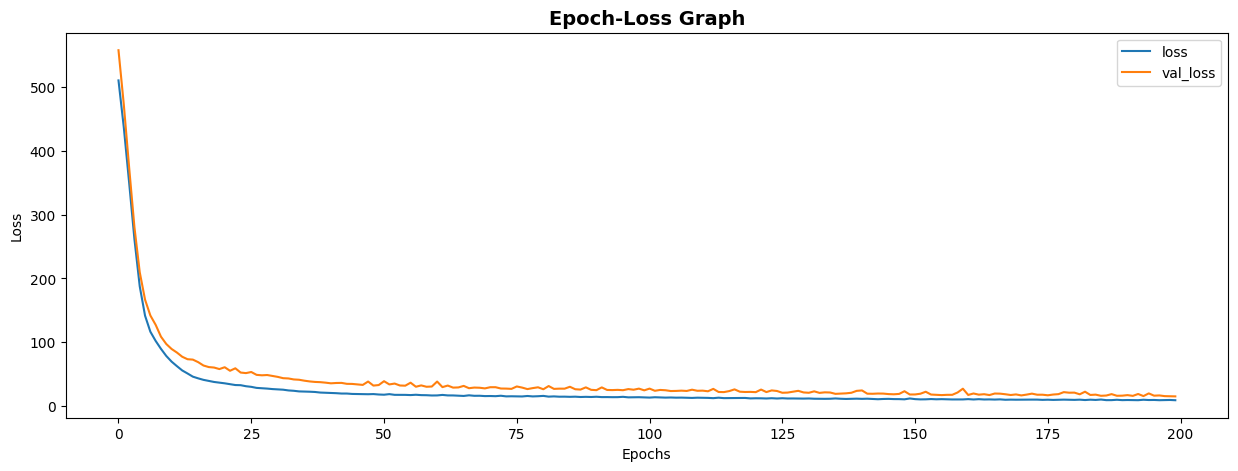

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.title('Epoch-Loss Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['loss'])
plt.plot(hist.epoch, hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

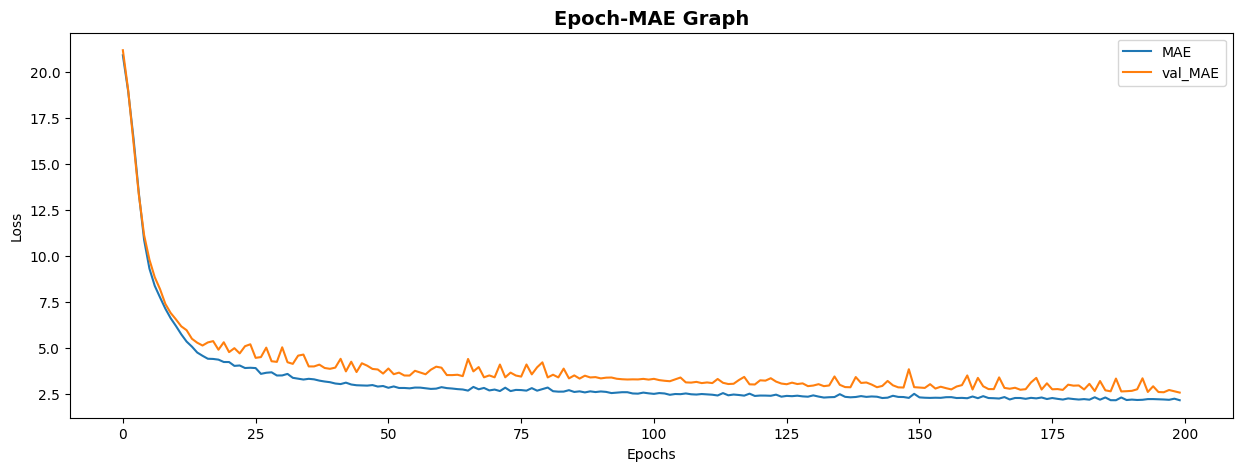

In [14]:
plt.figure(figsize=(15, 5))
plt.title('Epoch-MAE Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['mae'])
plt.plot(hist.epoch, hist.history['val_mae'])
plt.legend(['MAE', 'val_MAE'])
plt.show()

In [15]:
eval_result = model.evaluate(scaled_test_dataset_x, test_dataset_y)

for i in range(len(eval_result)):
    print(f'{model.metrics_names[i]}: {eval_result[i]}')

4/4 [==============================] - 0s 2ms/step - loss: 16.4959 - mae: 2.6566
loss: 16.49586296081543
mae: 2.6566381454467773


### Regresyon Modellerinin Sınıflandırılması

Girdiyle çıktı arasında ilişki kurma sürecine **"regresyon"** denilmektedir.  
Regresyon çeşitli biçimlerde yani çeşitli yöntemlerle gerçekleştirilebilmektedir.  
Aslında yapay sinir ağları da regresyon için bir yöntem grubunu oluşturmaktadır.  
Regresyon `y = f(x)` biçiminde uygun bir fonksiyonun bulunması sürecidir.  
Eğer biz böyle bir fonksiyon bulursak x değerlerini fonksiyonda yerine koyarak y değerini elde edebiliriz.  
Tabii `y = f(x)` fonksiyonunda x birden fazla değişkeni temsil ediyor olabilir.  
Benzer biçimde bu eşitlikte f fonksiyonu birden fazla değer de veriyor olabilir.

---

### İstatistikte Regresyon Sınıflamaları

İstatistikte regresyon işlemleri tipik olarak aşağıdaki gibi sınıflandırılmaktadır:

- Eğer bağımsız değişken bir tane ise buna genellikle **"basit regresyon (simple regression)"** denilmektedir.
- Eğer x birden fazla ise buna da genellikle **"çoklu regresyon (multiple regression)"** denilmektedir.
- İstatistikte regresyonun çıktısı kategorik değerler ise yani f fonksiyonu bir kategori değeri üretiyorsa buna  
  **"lojistik regresyon (logistics regression)"** ya da **"logit regresyonu"** denilmektedir.
